# STA 141B Project 

## Dealing with the Population Dataset and Car Accidents or Insurance
This part of the project showcases the code for showcasing the dataset

### Libraries needed for this part of the project

In [11]:
import os
import numpy as np
import pandas as pd
import sqlite3 as sq
import requests
import sys
import kagglehub
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\Carol\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


### Importing and cleaning the dataset for population

In [5]:
path_population = "C:/Users/Carol/Downloads/STA 141B/us_pop_by_state.csv" #Replace the path with your own path

if os.path.exists(path_population):
    print("File was found.")
else:
    print("File could not be found. Please change the path_population accordingly.") #Makes sure the path exists

df_population = pd.read_csv(path_population)

File was found.


In [17]:
df_population.info() #To see an overview of the data (any missing data, data type, etc.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              51 non-null     float64
 1   state             52 non-null     object 
 2   state_code        52 non-null     object 
 3   2020_census       52 non-null     int64  
 4   percent_of_total  51 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.2+ KB


In [6]:
#Cleaning the data since rank and percent_of_total is missing some data with the median
df_population[["rank", "percent_of_total"]] = df_population[["rank", "percent_of_total"]].fillna(df_population[["rank", "percent_of_total"]].median())
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              52 non-null     float64
 1   state             52 non-null     object 
 2   state_code        52 non-null     object 
 3   2020_census       52 non-null     int64  
 4   percent_of_total  52 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.2+ KB


In [23]:
#To see what the data looks like
df_population = df_population.sort_values(by='state')
df_population.head()

,rank,state,state_code,2020_census,percent_of_total
23,24.0,Alabama,AL,5024279,0.0148
47,48.0,Alaska,AK,733391,0.0022
13,14.0,Arizona,AZ,7151502,0.0219
32,33.0,Arkansas,AR,3011524,0.0091
0,1.0,California,CA,39538223,0.1191


### Importing and cleaning the dataset for Car Accidents (Only 2020)

In [7]:
path_accidents = "C:/Users/Carol/Downloads/STA 141B/US_Accidents_March23.csv" #Replace the path with your own path

if os.path.exists(path_accidents):
    print("File was found.")
else:
    print("File could not be found. Please change the path_accidents accordingly.") #Makes sure the path exists

df_accidents = pd.read_csv(path_accidents)

File was found.


In [23]:
df_accidents.info() #To see an overview of the data (any missing data, data type, etc.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

Looks like the car accidents dataset is not missing any data.

In [24]:
df_accidents.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [8]:
#Converting the columns into date time
df_accidents["Start_Time"] = pd.to_datetime(df_accidents["Start_Time"], format="mixed")
df_accidents["End_Time"] = pd.to_datetime(df_accidents["End_Time"], format="mixed")

#Keeping only 2020 data
df_accidents_2020 = df_accidents[df_accidents["Start_Time"].dt.year == 2020]

df_accidents_2020.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
1179737,A-1189513,Source2,2,2020-12-28 05:55:31,2021-01-18 05:00:00,39.376530,-74.478561,NaN,NaN,0.46,...,False,False,False,False,False,False,Night,Night,Night,Day
1198210,A-1207989,Source2,3,2020-12-31 22:57:02,2021-01-01 00:29:02,41.932789,-88.038078,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
1198211,A-1207990,Source2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,41.623920,-87.680061,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
1198212,A-1207991,Source2,3,2020-12-31 22:58:36,2021-01-01 01:02:45,41.794476,-87.631599,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night
1198349,A-1208128,Source2,2,2020-12-31 23:32:07,2021-01-01 00:51:14,39.771069,-104.847038,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night


### Graphing to see if the population and the car accidents have a relationship

In [9]:
#Counts how many accidents there are per state
accidents_per_state = df_accidents_2020.groupby("State").size().reset_index(name="accidents_count")
accidents_per_state.head()

,State,accidents_count
0,AL,20185
1,AR,3090
2,AZ,29535
3,CA,285532
4,CO,13889


<Figure size 640x480 with 0 Axes>

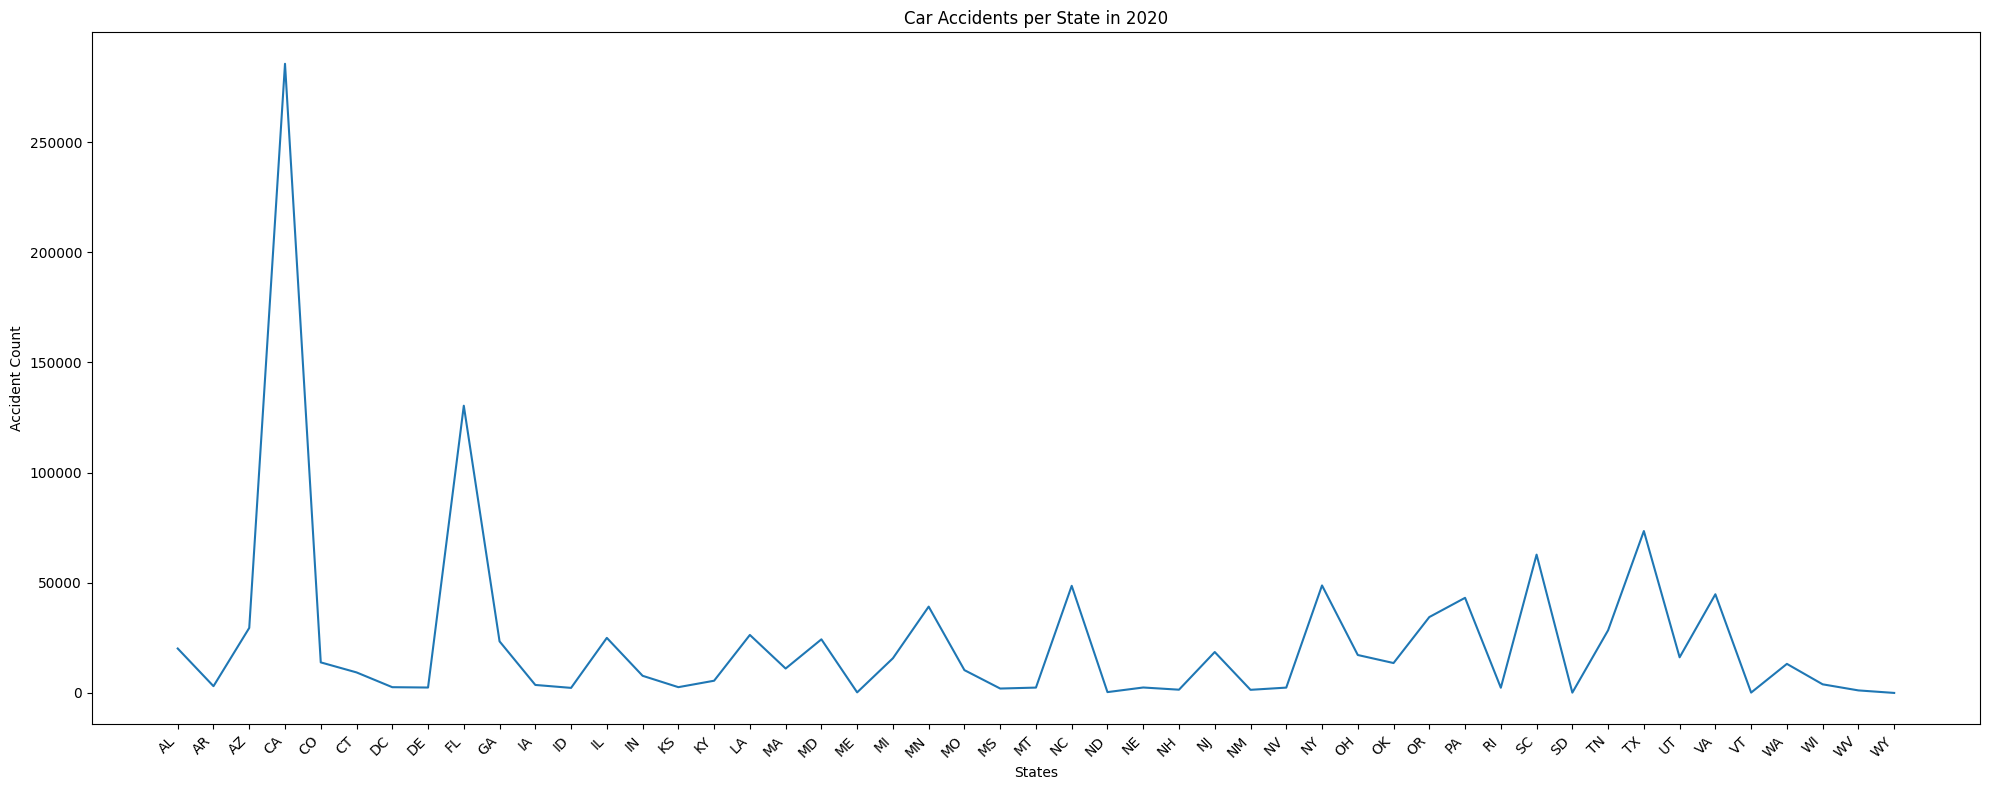

In [26]:
#Creating the graph for the accidents per state

plt.figure()

plt.figure(figsize=(20,8))

plot_accidents = sns.lineplot(
    data = accidents_per_state,
    x = "State",
    y = "accidents_count"
)

plot_accidents.set_title("Car Accidents per State in 2020")
plot_accidents.set_xlabel("States")
plot_accidents.set_ylabel("Accident Count")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

#plt.savefig("car_accidents_per_state.png")
#Above line is used for saving the image

plt.show()

In [21]:
plt.close()

<Figure size 640x480 with 0 Axes>

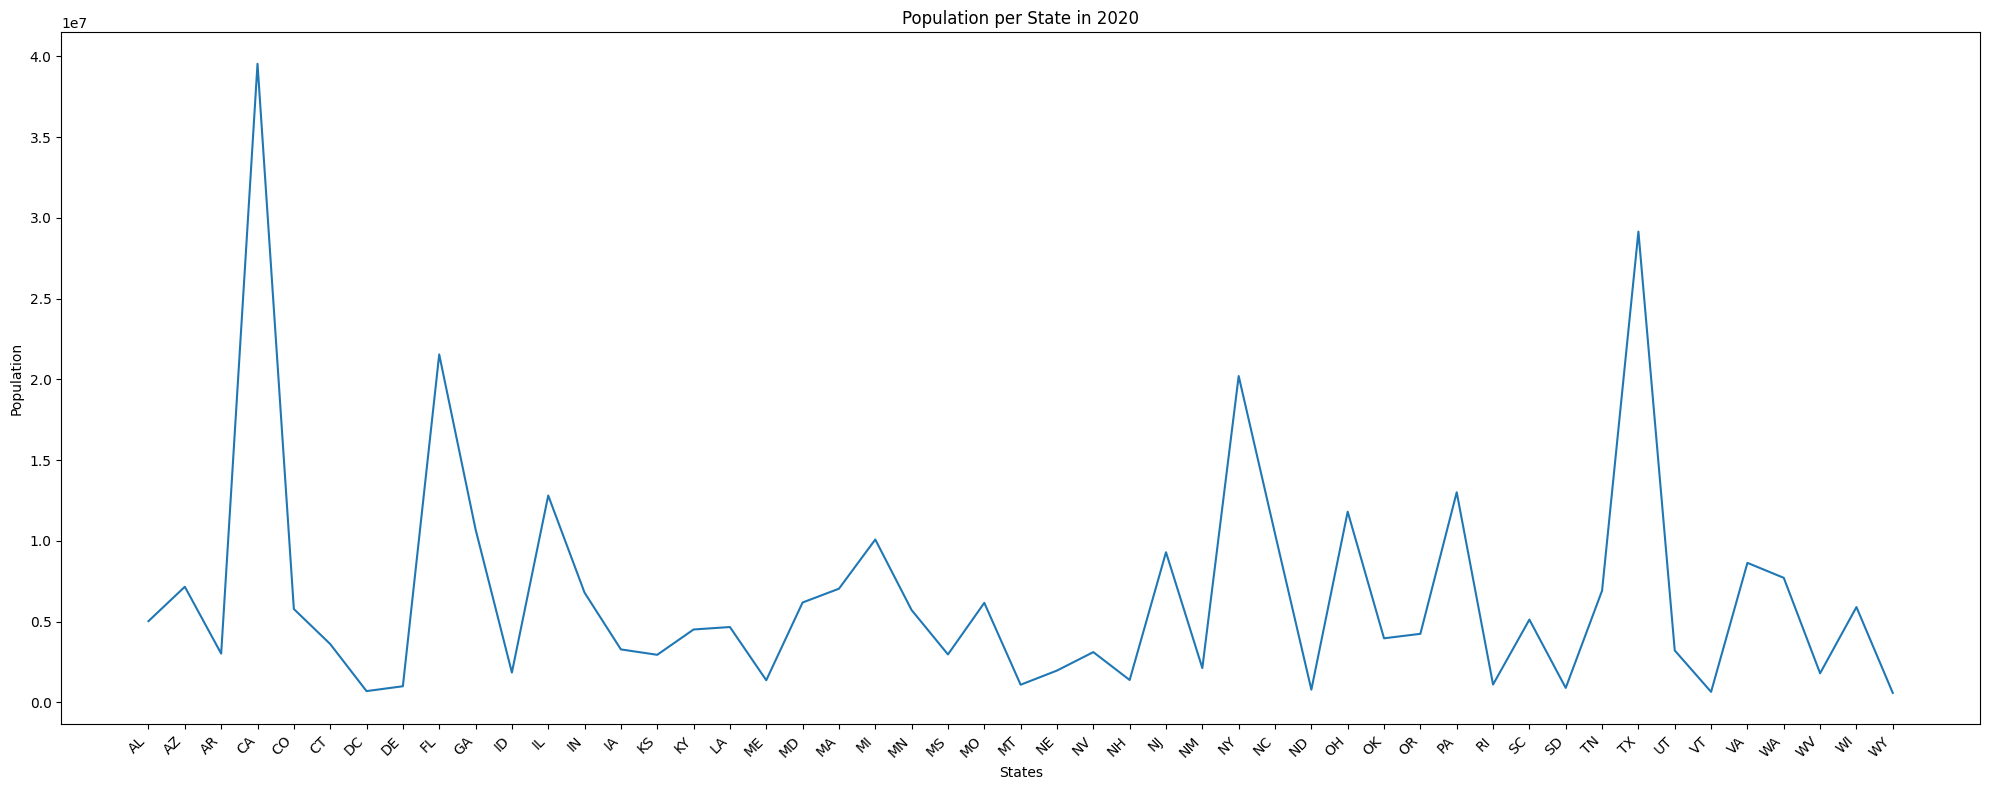

In [27]:
#Creating the graph for the population per state

#Found out some of the states in the population is not in the accidents, so I made sure they have the same data
states = accidents_per_state["State"].unique()
df_population = df_population[df_population["state_code"].isin(states)]

plt.figure()

plt.figure(figsize=(20,8))

plot_pop = sns.lineplot(
    data = df_population,
    x = "state_code",
    y = "2020_census"
)

plot_pop.set_title("Population per State in 2020")
plot_pop.set_xlabel("States")
plot_pop.set_ylabel("Population")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

#plt.savefig("population_per_state.png")
#Above line is used for saving the image

plt.show()

In [28]:
plt.close()

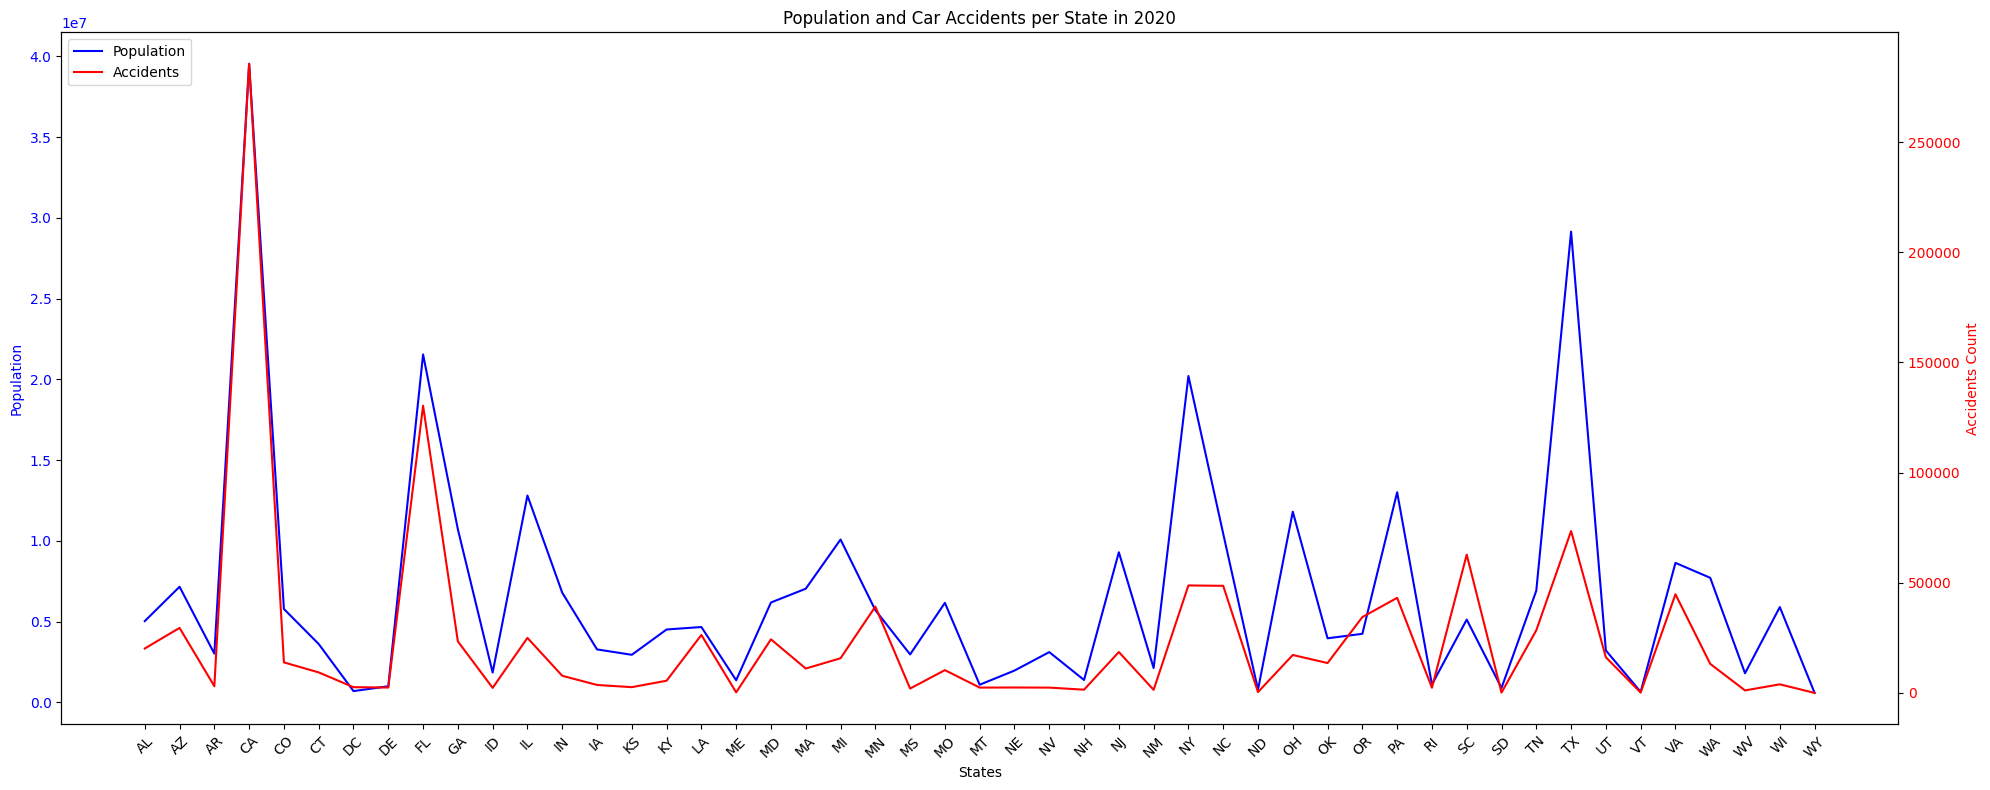

In [39]:
fig, ax1 = plt.subplots(figsize=(20,8))

# Plot Population on the left y-axis
sns.lineplot(
    data = df_population,
    x = "state_code",
    y = "2020_census",
    color = "blue",
    label = "Population",
    ax = ax1
)
ax1.set_xlabel("States") #They both share the same x_label
ax1.set_ylabel("Population", color="blue") #Puts the y-axis label for population on the left
ax1.tick_params(axis='y', labelcolor="blue")
ax1.tick_params(axis='x', rotation=45)

# Plot Accidnets on the right y-axis
ax2 = ax1.twinx()
sns.lineplot(
    data = accidents_per_state,
    x = "State",
    y = "accidents_count",
    color = "red",
    label = "Accidents",
    ax = ax2,
    legend = False
)
ax2.set_ylabel("Accidents Count", color = "red") #Adds the y-label on the right side
ax2.tick_params(axis = 'y', labelcolor = "red") 

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels() 
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left") #Creates the legend containing the lines and their color as well as their associated plot

plt.title("Population and Car Accidents per State in 2020")
plt.tight_layout()

#plt.savefig("population_and_car_accidents.png")
#Above line is used for saving the image

plt.show()

### Looking into correlation between the two datasets by merging them

In [43]:
#Merging the data
merged_data = df_population.merge(
    accidents_per_state,
    left_on = "state_code",
    right_on = "State"
)

merged_data.head()

,rank,state,state_code,2020_census,percent_of_total,State,accidents_count
0,24.0,Alabama,AL,5024279,0.0148,AL,20185
1,14.0,Arizona,AZ,7151502,0.0219,AZ,29535
2,33.0,Arkansas,AR,3011524,0.0091,AR,3090
3,1.0,California,CA,39538223,0.1191,CA,285532
4,21.0,Colorado,CO,5773714,0.0174,CO,13889


Since we only want the population (2020_census), State (we can keep the states full name and abbreviation), and accidents_count we will be dropping the other columns!

In [44]:
#Dropping unnecessary/repeating columns
merged_data = merged_data.drop(columns = ["rank", "percent_of_total", "State"]) 

merged_data.head()

,state,state_code,2020_census,accidents_count
0,Alabama,AL,5024279,20185
1,Arizona,AZ,7151502,29535
2,Arkansas,AR,3011524,3090
3,California,CA,39538223,285532
4,Colorado,CO,5773714,13889


In [45]:
#Calculating the correlation between the population and the accidents count
correlation = merged_data["2020_census"].corr(merged_data["accidents_count"])

print(f"Correlation between the population and accidents in 2020: {correlation}")

Correlation between the population and accidents in 2020: 0.8634703703278077


If correlation: <br>
&nbsp;&nbsp;&nbsp;1 = Perfect positive correlation (As one value increases the other value also increases) <br>
&nbsp;&nbsp;&nbsp;0 = No correlation <br>
&nbsp;&nbsp;&nbsp;-1 = Perfect negative correlation (As one value increases the other value decreases)

Because our correlation is about 0.86 this tells us that there is a positive correlation between the two variables. So, as populatioin increases in a state so does their car accidents.

### Calculating the R^2

Essentially I am calculating R^2 to see whether the population of a state can help predict how many car accidents occur in that state. I am using R^2 because it measures "how much of the variation of a dependent variable (car accidents) is explained by an independent variable (population) in a regression model."

In [46]:
population = merged_data["2020_census"].values #X variable
accidents = merged_data["accidents_count"].values #Y variable

#Calculating the means
pop_mean = np.mean(population) #x-mean
acci_mean = np.mean(accidents) #y-mean

#Calculating the slope
m = np.sum((population - pop_mean) * (accidents - acci_mean)) / np.sum((population - pop_mean)**2)

#Calculating the intercept
b = acci_mean - m * pop_mean

#Accident prediction values
acci_pred = m * population + b

#Calculating the sum of squared residuals (RSS)
rss = np.sum((accidents - acci_pred)**2)

#Calculating the total sum of squares
tss = np.sum((accidents - acci_mean)**2)

#Calculating R^2
r_squared = 1 - (rss / tss)

print(f"R^2 = {r_squared}")

R^2 = 0.7455810804340411


Coefficient of determination (R^2): <br>
&nbsp;&nbsp;&nbsp; 0 = The model does not predict the accidents <br>
&nbsp;&nbsp;&nbsp; Between 0 and 1 = The model partially predicts the accidents <br>
&nbsp;&nbsp;&nbsp; 1 = The model perfectly predicts the outcome

The R^2 is 0.746 which means that the population of a state can explain about 74.6% of the differences in car accidents. This would mean that states with larger populations generally have more accidents, so population is a strong predictor to accident counts.

### Showing the linear regression model

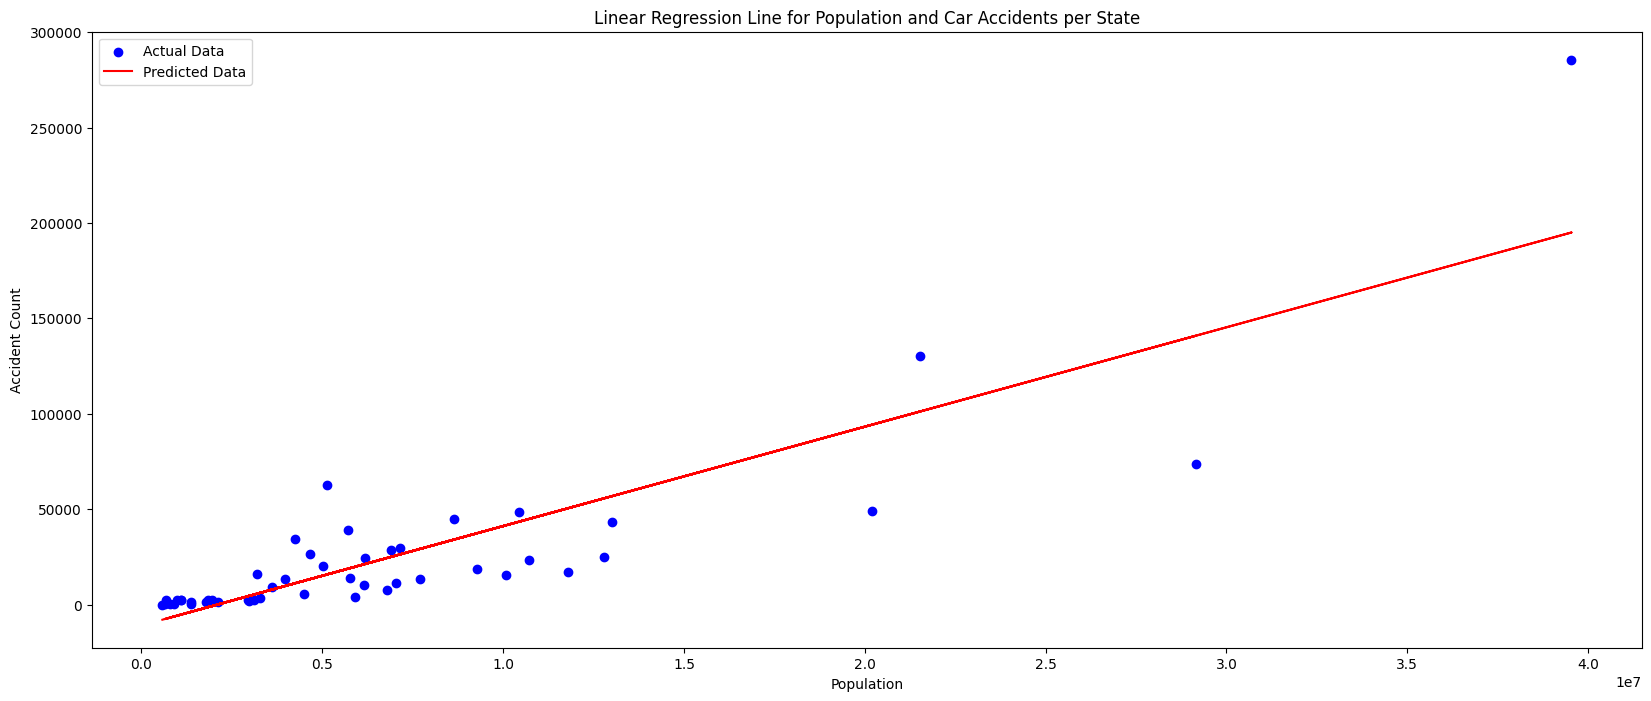

In [49]:
plt.figure(figsize = (20,8))
plt.scatter(population, accidents, color = "blue", label = "Actual Data")
plt.plot(population, acci_pred, color = "red", label = "Predicted Data")

plt.title("Linear Regression Line for Population and Car Accidents per State")
plt.xlabel("Population")
plt.ylabel("Accident Count")
plt.legend()

#plt.savefig("linear_regression_population_accident.png")
#Above line is used for saving the image

plt.show()